In [22]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin

# Modelli
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

In [23]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

In [24]:
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_clean[(df_clean[col] < Q1 - 2.0*IQR) | (df_clean[col] > Q3 + 2.0*IQR)].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"   -> Dataset pulito: {df.shape}")

   -> Dataset pulito: (18223, 9)


In [25]:
# ---------------------------------------------------------
# 2. FEATURE ENGINEERING MASSIVA
# ---------------------------------------------------------
print("2. Generazione Feature 'Combo' (Multiplicazioni, Divisioni, Log)...")

def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Generazione combinazioni su {len(math_cols)} colonne base...")

    # A. LOGARITMI
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MOLTIPLICAZIONI
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONI / RAPPORTI
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

# --- Geo Features Base ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

coords = df[['Latitude', 'Longitude']]
# KMeans (Cluster geografici)
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(coords))

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_comprehensive_features(X, cols_for_math)

# Pulizia inf/nan generati dalle divisioni
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)

print(f"   -> Totale Feature Generate: {X_full.shape[1]}")

#ridimensionamento 
df = df.sample(frac=0.20, random_state=42, axis = 0)


2. Generazione Feature 'Combo' (Multiplicazioni, Divisioni, Log)...
   -> Generazione combinazioni su 8 colonne base...
   -> Totale Feature Generate: 103


In [26]:
# ---------------------------------------------------------
# 3. SELEZIONE FEATURE CON XGBOOST GPU
# ---------------------------------------------------------
print("3. Selezione Feature tramite CPU...")
scaler = RobustScaler()
# Nota: fit non richiede scaling per alberi, ma utile averlo per prassi
X_scaled = scaler.fit_transform(X_full)

selector_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    tree_method='hist', device='cpu', n_jobs=-1, random_state=42
)
selector_model.fit(X_full, y)
selection = SelectFromModel(selector_model, prefit=True, threshold='1.25*median')

X_selected = X_full.loc[:, selection.get_support()]
print(f"   -> Feature Sopravvissute: {X_selected.shape[1]}")

# Split Principale (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

3. Selezione Feature tramite CPU...
   -> Feature Sopravvissute: 37


In [27]:
# ---------------------------------------------------------
# 4. OPTUNA REALE CON EARLY STOPPING CORRETTO
# ---------------------------------------------------------
print("\n4. Tuning Iperparametri con Optuna e Early Stopping...")

# Creiamo un set di validazione SOLO per Optuna per monitorare l'early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 20  # Numero di trial (aumentare per risultati migliori)

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    
    model = XGBRegressor(**params)
    
    # Verbose=False sopprime i log, eval_set serve per l'early stopping
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    
    model = CatBoostRegressor(**params)
    
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        early_stopping_rounds=100
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization (New Callback API) ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    
    model = LGBMRegressor(**params)
    
    # NEW API: Usiamo callbacks invece di early_stopping_rounds in .fit()
    callbacks = [
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=0) # Zittisce l'output
    ]
    
    try:
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    except Exception as e:
        # Fallback CPU se GPU crasha o non presente
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )

    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Recupero i migliori parametri
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1, 'random_state': 42})
# Rimuoviamo early_stopping_rounds dai params per il fit finale (opzionale, ma pulito)
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'task_type': 'CPU', 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'device': 'cpu', 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

print("\n--- Optuna Completato. Parametri migliori trovati. ---")


[I 2025-12-10 12:39:31,925] A new study created in memory with name: no-name-1c706424-e495-44ab-8f18-732b897b6abb



4. Tuning Iperparametri con Optuna e Early Stopping...
   -> Optimizing XGBoost...


[I 2025-12-10 12:39:37,046] Trial 0 finished with value: 0.5100534866729494 and parameters: {'n_estimators': 999, 'learning_rate': 0.5955231814694583, 'max_depth': 16, 'subsample': 0.8348175195192886, 'colsample_bytree': 0.9100743776685692, 'alpha': 5.382882595781807e-09, 'lambda': 0.033684438690666556}. Best is trial 0 with value: 0.5100534866729494.
[I 2025-12-10 12:39:46,253] Trial 1 finished with value: 0.45319551005387165 and parameters: {'n_estimators': 789, 'learning_rate': 0.4510741606125317, 'max_depth': 14, 'subsample': 0.8896321687476334, 'colsample_bytree': 0.81554800989841, 'alpha': 0.8778754875708247, 'lambda': 6.222846459629335e-05}. Best is trial 1 with value: 0.45319551005387165.
[I 2025-12-10 12:39:50,530] Trial 2 finished with value: 0.40508051848857296 and parameters: {'n_estimators': 1191, 'learning_rate': 0.231701599394957, 'max_depth': 4, 'subsample': 0.7806048889264683, 'colsample_bytree': 0.8012312414147096, 'alpha': 4.376655830032972e-06, 'lambda': 4.922100972

   -> Optimizing CatBoost...


[I 2025-12-10 12:43:28,222] Trial 0 finished with value: 0.4037045017143651 and parameters: {'iterations': 1027, 'learning_rate': 0.3375410297444968, 'depth': 10, 'l2_leaf_reg': 8.068266021290261, 'subsample': 0.8625689998275512}. Best is trial 0 with value: 0.4037045017143651.
[I 2025-12-10 12:43:40,378] Trial 1 finished with value: 0.3844240250090407 and parameters: {'iterations': 1197, 'learning_rate': 0.05005426166103499, 'depth': 8, 'l2_leaf_reg': 9.624227132921567, 'subsample': 0.6870960707876357}. Best is trial 1 with value: 0.3844240250090407.
[I 2025-12-10 12:43:42,337] Trial 2 finished with value: 0.3899538913055416 and parameters: {'iterations': 1002, 'learning_rate': 0.19968407781880973, 'depth': 4, 'l2_leaf_reg': 4.05288327546777, 'subsample': 0.8768225555181006}. Best is trial 1 with value: 0.3844240250090407.
[I 2025-12-10 12:43:44,106] Trial 3 finished with value: 0.3939596708278272 and parameters: {'iterations': 827, 'learning_rate': 0.3256110497685582, 'depth': 6, 'l2

   -> Optimizing LightGBM...


[I 2025-12-10 12:44:50,041] Trial 0 finished with value: 0.4304683065581154 and parameters: {'n_estimators': 1186, 'learning_rate': 0.6113278691592533, 'num_leaves': 49, 'feature_fraction': 0.6425338339050356, 'bagging_fraction': 0.8896813122421082, 'bagging_freq': 1, 'reg_alpha': 5.325694002021671, 'reg_lambda': 8.672368036360297}. Best is trial 0 with value: 0.4304683065581154.
[I 2025-12-10 12:44:52,760] Trial 1 finished with value: 0.3862616566737266 and parameters: {'n_estimators': 906, 'learning_rate': 0.11029791532164522, 'num_leaves': 29, 'feature_fraction': 0.6325325715974658, 'bagging_fraction': 0.7771370637284837, 'bagging_freq': 4, 'reg_alpha': 0.09547056769608217, 'reg_lambda': 8.30444502547726}. Best is trial 1 with value: 0.3862616566737266.
[I 2025-12-10 12:44:54,081] Trial 2 finished with value: 0.44707283551774085 and parameters: {'n_estimators': 848, 'learning_rate': 0.7717026935387231, 'num_leaves': 73, 'feature_fraction': 0.8757157888240426, 'bagging_fraction': 0.8


--- Optuna Completato. Parametri migliori trovati. ---


In [28]:
# ---------------------------------------------------------
# 5. SMART SOFT MODEL SELECTOR (Mixture of Experts)
# ---------------------------------------------------------
print("\n5. Costruzione Smart Soft Selector (Mixture of Experts)...")

class SmartSoftModelSelector(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, selector_model=None):
        self.estimators = estimators # Lista di tuple ('nome', modello)
        # Usiamo XGBClassifier su cpu come selettore per massima velocità
        self.selector_model = selector_model if selector_model else XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', device='cpu', n_jobs=-1, random_state=42
        )
        self.model_names = [name for name, _ in estimators]
        
    def fit(self, X, y):
        # A. Addestramento Modelli Base
        print("   -> Training modelli base (Esperti) su tutto il Train Set...")
        self.fitted_estimators_ = []
        for name, model in self.estimators:
            # Nota: Qui non usiamo Early Stopping perché vorremmo usare tutto il train set.
            # Usiamo i parametri ottimizzati da Optuna che sono robusti.
            model.fit(X, y)
            self.fitted_estimators_.append(model)
            
        # B. Generazione OOF Predictions (Chi sbaglia meno dove?)
        print("   -> Generazione dati per il Gating Network...")
        errors = pd.DataFrame()
        
        # Nota: Usiamo n_jobs=1 in cross_val_predict perché i modelli usano cpu internamente
        for name, model in self.estimators:
            # cross_val_predict è essenziale per evitare leakage
            oof_preds = cross_val_predict(model, X, y, cv=5, n_jobs=1)
            errors[name] = np.abs(y - oof_preds) # Errore Assoluto
            
        # C. Creazione Target per il Selettore
        y_best_model_idx = errors.idxmin(axis=1).apply(lambda x: self.model_names.index(x))
        
        # D. Addestramento Selettore (Gating Network)
        print("   -> Training del Selettore (Gating Network)...")
        self.selector_model.fit(X, y_best_model_idx)
        return self

    def predict(self, X):
        # A. Predizioni Base
        base_preds = np.column_stack([model.predict(X) for model in self.fitted_estimators_])
        # B. Pesi Soft
        weights = self.selector_model.predict_proba(X)
        # C. Media Ponderata Dinamica
        final_pred = np.sum(base_preds * weights, axis=1)
        return final_pred

# Istanziamo i modelli base con i Best Params di Optuna
estimators_list = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params)) 
]

# Creiamo e addestriamo il sistema MoE
moe_model = SmartSoftModelSelector(estimators=estimators_list)
moe_model.fit(X_train, y_train)


5. Costruzione Smart Soft Selector (Mixture of Experts)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...


SmartSoftModelSelector(estimators=[('xgb',
                                    XGBRegressor(alpha=4.028201707299821e-05,
                                                 base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=0.781318837764291,
                                                 device='cpu',
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None,
                                                 feature_weights=None,
                                                 gamma=None, grow_polic...
                                                    feature_weights=None,
                                                    gamma=None,
                                                    grow_policy=None,
                                                    importance_type=None,
                                                    interaction_constraints=None,
                                                    learning_rate=0.05,
                                                    max_bin=None,
                                                    max_cat_threshold=None,
                                                    max_cat_to_onehot=None,
                                                    max_delta_step=None,
                                                    max_depth=6,
                                                    max_leaves=None,
                                                    min_child_weight=None,
                                                    missing=nan,
                                                    monotone_constraints=None,
                                                    multi_strategy=None,
                                                    n_estimators=200, n_jobs=-1,
                                                    num_parallel_tree=None, ...))


6. Training Correttore dei Residui...
   -> Calcolo residui OOF (può richiedere tempo)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...
   -> Training modelli base (Esperti) su tutto il Train Set...
   -> Generazione dati per il Gating Network...
   -> Training del Selettore (Gating Network)...
      Media Residui: 0.0015
      Deviaz. Std Residui: 0.3820
   -> Training del Correttore...

 RISULTATI FI

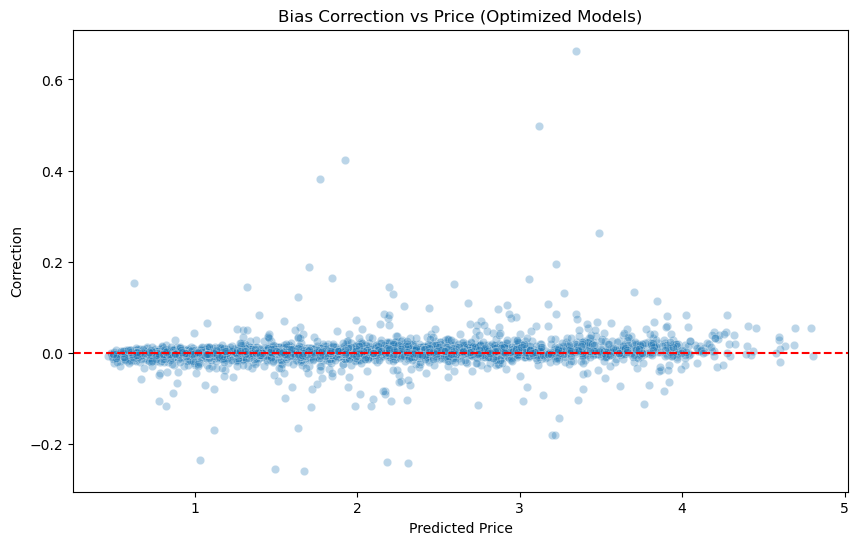

In [29]:
# ---------------------------------------------------------
# 6. AGGIUNTA DEL CORRETTORE DEI RESIDUI (Residual Learning)
# ---------------------------------------------------------
print("\n6. Training Correttore dei Residui...")

class ResidualCorrectedMoE(BaseEstimator, RegressorMixin):
    def __init__(self, base_moe_model, corrector_model=None):
        self.base_moe_model = base_moe_model
        # Usiamo un CatBoost leggero come correttore
        self.corrector_model = corrector_model if corrector_model else CatBoostRegressor(
            iterations=500,          
            depth=6, 
            learning_rate=0.03,
            l2_leaf_reg=5,           
            task_type='CPU', 
            devices='0',
            verbose=0,
            allow_writing_files=False,
            random_state=42
        )
        
    def fit(self, X, y):
        
        # 2. Generiamo le predizioni OOF per calcolare i residui onesti
        print("   -> Calcolo residui OOF (può richiedere tempo)...")
        oof_preds = cross_val_predict(self.base_moe_model, X, y, cv=5, n_jobs=1)
        
        # 3. Calcolo dell'Errore
        residuals = y - oof_preds
        
        print(f"      Media Residui: {residuals.mean():.4f}")
        print(f"      Deviaz. Std Residui: {residuals.std():.4f}")
        
        # 4. Addestriamo il Correttore
        print("   -> Training del Correttore...")
        self.corrector_model.fit(X, residuals)
        return self

    def predict(self, X):
        base_pred = self.base_moe_model.predict(X)
        correction = self.corrector_model.predict(X)
        return base_pred + (1.0 * correction)

# Costruzione Finale
# Nota: passiamo il moe_model già addestrato, ma la classe ResidualCorrectedMoE
# userà cross_val_predict che internamente farà cloni e fit su fold.
final_system = ResidualCorrectedMoE(base_moe_model=moe_model)
final_system.fit(X_train, y_train)

# Valutazione
y_pred_corrected = final_system.predict(X_test)

final_rmse_corr = np.sqrt(mean_squared_error(y_test, y_pred_corrected))
final_r2_corr = r2_score(y_test, y_pred_corrected)

print(f"\n==========================================")
print(f" RISULTATI FINALI OTTIMIZZATI")
print(f"==========================================")
print(f" RMSE: {final_rmse_corr:.5f}")
print(f" R^2 : {final_r2_corr:.5f}")
print(f"==========================================")

# Plot veloce
corrections_test = final_system.corrector_model.predict(X_test)
base_preds_test = final_system.base_moe_model.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=base_preds_test, y=corrections_test, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Bias Correction vs Price (Optimized Models)")
plt.xlabel("Predicted Price")
plt.ylabel("Correction")
plt.show()